**Importing everything**

In [5]:
# --- Core data handling ---
import pandas as pd
import numpy as np
import time

# --- RDKit: molecule parsing and Morgan fingerprints ---
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import DataStructs

# --- Modeling ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score

# --- Plotting, for later sanity checks ---
import matplotlib.pyplot as plt

**Load data, compute Morgan fingerprints, inspect before combining with anything**

In [6]:
df = pd.read_csv("beard_model_ready_features.csv")

def get_morgan_fp(smi, radius=2, n_bits=256):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

n_bits = 256
fp_list = df["canonical_smi"].apply(get_morgan_fp)

# Check for any parsing failures before proceeding
n_failed = fp_list.isna().sum()
print(f"Fingerprint generation failures: {n_failed}")

fp_matrix = np.stack(fp_list.values)
fp_df = pd.DataFrame(fp_matrix, columns=[f"fp_{i}" for i in range(n_bits)])

print(f"Fingerprint matrix shape: {fp_df.shape}")
print(f"Average bits 'on' per compound: {fp_matrix.sum(axis=1).mean():.1f} out of {n_bits}")
print(f"Bits that are always 0 across all compounds (uninformative): {(fp_matrix.sum(axis=0) == 0).sum()}")
print(f"Bits that are always 1 across all compounds (uninformative): {(fp_matrix.sum(axis=0) == n_bits and fp_matrix.shape[0]).sum() if False else (fp_matrix.sum(axis=0) == fp_matrix.shape[0]).sum()}")

[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerator
[06:13:01] DEPRECATION WARNING: please use MorganGenerat

Fingerprint generation failures: 0
Fingerprint matrix shape: (6878, 256)
Average bits 'on' per compound: 34.4 out of 256
Bits that are always 0 across all compounds (uninformative): 0
Bits that are always 1 across all compounds (uninformative): 0


**Fingerprint-only train/test split, scaling, and Ridge baseline**

In [7]:
X_fp = fp_df.copy()
y_fp = df["lambda_max_exp_nm"].reset_index(drop=True)

X_train_fp, X_test_fp, y_train_fp, y_test_fp = train_test_split(
    X_fp, y_fp, test_size=0.2, random_state=42
)

print(f"Train: {X_train_fp.shape}, Test: {X_test_fp.shape}")

Train: (5502, 256), Test: (1376, 256)


**Scalling**

In [8]:
scaler_fp = StandardScaler()
X_train_fp_scaled = scaler_fp.fit_transform(X_train_fp)
X_test_fp_scaled = scaler_fp.transform(X_test_fp)

**Fit Ridge with cross-validated alpha**

In [9]:
ridge_fp = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0], cv=5)
ridge_fp.fit(X_train_fp_scaled, y_train_fp)

y_pred_fp = ridge_fp.predict(X_test_fp_scaled)
rmse_fp = np.sqrt(mean_squared_error(y_test_fp, y_pred_fp))
r2_fp = r2_score(y_test_fp, y_pred_fp)

print(f"Ridge, fingerprint only (256 bits): RMSE = {rmse_fp:.2f} nm, R² = {r2_fp:.3f}")
print(f"Best alpha: {ridge_fp.alpha_}")

Ridge, fingerprint only (256 bits): RMSE = 110.99 nm, R² = 0.210
Best alpha: 1000.0


**check**

In [10]:
ridge_fp_v2 = RidgeCV(alphas=[100, 500, 1000, 2000, 5000, 10000, 50000], cv=5)
ridge_fp_v2.fit(X_train_fp_scaled, y_train_fp)

y_pred_fp_v2 = ridge_fp_v2.predict(X_test_fp_scaled)
rmse_fp_v2 = np.sqrt(mean_squared_error(y_test_fp, y_pred_fp_v2))
r2_fp_v2 = r2_score(y_test_fp, y_pred_fp_v2)

print(f"Ridge, fingerprint only, wider alpha search: RMSE = {rmse_fp_v2:.2f} nm, R² = {r2_fp_v2:.3f}")
print(f"Best alpha: {ridge_fp_v2.alpha_}")

Ridge, fingerprint only, wider alpha search: RMSE = 110.99 nm, R² = 0.210
Best alpha: 1000


**Add LargestConjugatedSystemSize and HasPushPull on top**

In [11]:
X_fp_mech = pd.concat([
    fp_df.reset_index(drop=True),
    df[["LargestConjugatedSystemSize", "HasPushPull"]].reset_index(drop=True)
], axis=1)

X_train_fpm, X_test_fpm, y_train_fpm, y_test_fpm = train_test_split(
    X_fp_mech, y_fp, test_size=0.2, random_state=42
)

scaler_fpm = StandardScaler()
X_train_fpm_scaled = scaler_fpm.fit_transform(X_train_fpm)
X_test_fpm_scaled = scaler_fpm.transform(X_test_fpm)

ridge_fpm = RidgeCV(alphas=[100, 500, 1000, 2000, 5000, 10000], cv=5)
ridge_fpm.fit(X_train_fpm_scaled, y_train_fpm)

y_pred_fpm = ridge_fpm.predict(X_test_fpm_scaled)
rmse_fpm = np.sqrt(mean_squared_error(y_test_fpm, y_pred_fpm))
r2_fpm = r2_score(y_test_fpm, y_pred_fpm)

print(f"Ridge, fingerprint + conjugation + push-pull: RMSE = {rmse_fpm:.2f} nm, R² = {r2_fpm:.3f}")
print(f"Best alpha: {ridge_fpm.alpha_}")
print(f"\nFor comparison:")
print(f"Fingerprint only:                    RMSE = 110.99 nm, R² = 0.210")

Ridge, fingerprint + conjugation + push-pull: RMSE = 109.90 nm, R² = 0.225
Best alpha: 1000

For comparison:
Fingerprint only:                    RMSE = 110.99 nm, R² = 0.210


**Fingerprint + Conjugation & Fingerprint + Pushpull**

In [11]:
# Fingerprint + conjugation length only
X_fp_conj = pd.concat([
    fp_df.reset_index(drop=True),
    df[["LargestConjugatedSystemSize"]].reset_index(drop=True)
], axis=1)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_fp_conj, y_fp, test_size=0.2, random_state=42)
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

ridge_c = RidgeCV(alphas=[100, 500, 1000, 2000, 5000, 10000], cv=5)
ridge_c.fit(X_train_c_scaled, y_train_c)
y_pred_c = ridge_c.predict(X_test_c_scaled)
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
r2_c = r2_score(y_test_c, y_pred_c)
print(f"Fingerprint + conjugation only:  RMSE = {rmse_c:.2f} nm, R² = {r2_c:.3f}, alpha = {ridge_c.alpha_}")

# Fingerprint + push-pull only
X_fp_pp = pd.concat([
    fp_df.reset_index(drop=True),
    df[["HasPushPull"]].reset_index(drop=True)
], axis=1)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_fp_pp, y_fp, test_size=0.2, random_state=42)
scaler_p = StandardScaler()
X_train_p_scaled = scaler_p.fit_transform(X_train_p)
X_test_p_scaled = scaler_p.transform(X_test_p)

ridge_p = RidgeCV(alphas=[100, 500, 1000, 2000, 5000, 10000], cv=5)
ridge_p.fit(X_train_p_scaled, y_train_p)
y_pred_p = ridge_p.predict(X_test_p_scaled)
rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
r2_p = r2_score(y_test_p, y_pred_p)
print(f"Fingerprint + push-pull only:    RMSE = {rmse_p:.2f} nm, R² = {r2_p:.3f}, alpha = {ridge_p.alpha_}")

print(f"\nFor reference:")
print(f"Fingerprint only:                RMSE = 110.99 nm, R² = 0.210")
print(f"Fingerprint + both:              RMSE = 109.90 nm, R² = 0.225")

Fingerprint + conjugation only:  RMSE = 109.91 nm, R² = 0.225, alpha = 1000
Fingerprint + push-pull only:    RMSE = 111.00 nm, R² = 0.210, alpha = 1000

For reference:
Fingerprint only:                RMSE = 110.99 nm, R² = 0.210
Fingerprint + both:              RMSE = 109.90 nm, R² = 0.225


**Build the combined feature matrix, split, scale**

In [12]:
X_gp = pd.concat([
    fp_df.reset_index(drop=True),
    df[["LargestConjugatedSystemSize"]].reset_index(drop=True)
], axis=1)
y_gp = df["lambda_max_exp_nm"].reset_index(drop=True)

X_train_gp, X_test_gp, y_train_gp, y_test_gp = train_test_split(
    X_gp, y_gp, test_size=0.2, random_state=42
)

scaler_gp = StandardScaler()
X_train_gp_scaled = scaler_gp.fit_transform(X_train_gp)
X_test_gp_scaled = scaler_gp.transform(X_test_gp)

print(f"Train: {X_train_gp_scaled.shape}, Test: {X_test_gp_scaled.shape}")

Train: (5502, 257), Test: (1376, 257)


**Subsample for a fast diagnostic fit, isotropic kernel**

In [13]:
from sklearn.model_selection import train_test_split as tts

X_train_gp_sub, _, y_train_gp_sub, _ = tts(
    X_train_gp_scaled, y_train_gp, train_size=1500, random_state=42
)

kernel_gp_sub = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_fp_sub = GaussianProcessRegressor(
    kernel=kernel_gp_sub,
    n_restarts_optimizer=2,
    random_state=42
)

start = time.time()
gp_fp_sub.fit(X_train_gp_sub, y_train_gp_sub)
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_fp_sub.kernel_)

Done in 33.1 seconds.
159**2 * RBF(length_scale=25.7) + WhiteKernel(noise_level=1e+04)


**Evaluate on the test set**

In [14]:
y_pred_gp_sub, y_std_gp_sub = gp_fp_sub.predict(X_test_gp_scaled, return_std=True)

rmse_gp_sub = np.sqrt(mean_squared_error(y_test_gp, y_pred_gp_sub))
r2_gp_sub = r2_score(y_test_gp, y_pred_gp_sub)

print(f"GP (fingerprint + conjugation, 1500-subsample train): RMSE = {rmse_gp_sub:.2f} nm, R² = {r2_gp_sub:.3f}")
print(f"Mean predicted uncertainty: {y_std_gp_sub.mean():.2f} nm")
print(f"Std of predicted uncertainty: {y_std_gp_sub.std():.2f} nm")

print(f"\nFor comparison:")
print(f"Ridge, fingerprint + conjugation (full 5502 train): RMSE = 109.91 nm, R² = 0.225")

GP (fingerprint + conjugation, 1500-subsample train): RMSE = 109.39 nm, R² = 0.232
Mean predicted uncertainty: 113.40 nm
Std of predicted uncertainty: 5.46 nm

For comparison:
Ridge, fingerprint + conjugation (full 5502 train): RMSE = 109.91 nm, R² = 0.225


**Fair comparisn**

In [15]:
scaler_ridge_sub = StandardScaler()
X_train_ridge_sub_scaled = scaler_ridge_sub.fit_transform(X_train_gp_sub)
X_test_ridge_sub_scaled = scaler_ridge_sub.transform(X_test_gp)  # same test set throughout

ridge_sub = RidgeCV(alphas=[100, 500, 1000, 2000, 5000, 10000], cv=5)
ridge_sub.fit(X_train_ridge_sub_scaled, y_train_gp_sub)

y_pred_ridge_sub = ridge_sub.predict(X_test_ridge_sub_scaled)
rmse_ridge_sub = np.sqrt(mean_squared_error(y_test_gp, y_pred_ridge_sub))
r2_ridge_sub = r2_score(y_test_gp, y_pred_ridge_sub)

print(f"Ridge, SAME 1500-compound subsample: RMSE = {rmse_ridge_sub:.2f} nm, R² = {r2_ridge_sub:.3f}, alpha = {ridge_sub.alpha_}")
print(f"GP,    SAME 1500-compound subsample: RMSE = 109.39 nm, R² = 0.232")

/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Ridge, SAME 1500-compound subsample: RMSE = 263.53 nm, R² = -3.456, alpha = 1000
GP,    SAME 1500-compound subsample: RMSE = 109.39 nm, R² = 0.232


**Removing double scaling error**

In [16]:
ridge_sub_fixed = RidgeCV(alphas=[100, 500, 1000, 2000, 5000, 10000], cv=5)
ridge_sub_fixed.fit(X_train_gp_sub, y_train_gp_sub)  # already scaled, no re-scaling needed

y_pred_ridge_sub_fixed = ridge_sub_fixed.predict(X_test_gp_scaled)  # consistent scaling with training
rmse_ridge_sub_fixed = np.sqrt(mean_squared_error(y_test_gp, y_pred_ridge_sub_fixed))
r2_ridge_sub_fixed = r2_score(y_test_gp, y_pred_ridge_sub_fixed)

print(f"Ridge, SAME 1500-compound subsample (fixed scaling): RMSE = {rmse_ridge_sub_fixed:.2f} nm, R² = {r2_ridge_sub_fixed:.3f}, alpha = {ridge_sub_fixed.alpha_}")
print(f"GP,    SAME 1500-compound subsample:                  RMSE = 109.39 nm, R² = 0.232")

Ridge, SAME 1500-compound subsample (fixed scaling): RMSE = 112.13 nm, R² = 0.193, alpha = 1000
GP,    SAME 1500-compound subsample:                  RMSE = 109.39 nm, R² = 0.232


**Intermediate size check (3,000 compounds),**

In [18]:
X_train_gp_mid, _, y_train_gp_mid, _ = tts(
    X_train_gp_scaled, y_train_gp, train_size=3000, random_state=42
)

kernel_gp_mid = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_fp_mid = GaussianProcessRegressor(
    kernel=kernel_gp_mid,
    n_restarts_optimizer=2,
    random_state=42
)

start = time.time()
gp_fp_mid.fit(X_train_gp_mid, y_train_gp_mid)
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_fp_mid.kernel_)

y_pred_gp_mid, y_std_gp_mid = gp_fp_mid.predict(X_test_gp_scaled, return_std=True)
rmse_gp_mid = np.sqrt(mean_squared_error(y_test_gp, y_pred_gp_mid))
r2_gp_mid = r2_score(y_test_gp, y_pred_gp_mid)

print(f"GP (3000-compound train): RMSE = {rmse_gp_mid:.2f} nm, R² = {r2_gp_mid:.3f}")
print(f"Uncertainty std: {y_std_gp_mid.std():.2f} nm")
print(f"\nFor reference:")
print(f"GP (1500-compound train): RMSE = 109.39 nm, R² = 0.232")
print(f"Ridge (full 5502 train):  RMSE = 109.91 nm, R² = 0.225")

Done in 198.1 seconds.
162**2 * RBF(length_scale=19.1) + WhiteKernel(noise_level=7.31e+03)
GP (3000-compound train): RMSE = 101.25 nm, R² = 0.342
Uncertainty std: 9.31 nm

For reference:
GP (1500-compound train): RMSE = 109.39 nm, R² = 0.232
Ridge (full 5502 train):  RMSE = 109.91 nm, R² = 0.225


In [19]:
# Export exact train/test arrays for Colab, so the fit is on IDENTICAL data
np.save("X_train_gp_scaled.npy", X_train_gp_scaled)
np.save("X_test_gp_scaled.npy", X_test_gp_scaled)
np.save("y_train_gp.npy", y_train_gp.values)
np.save("y_test_gp.npy", y_test_gp.values)
print("Saved arrays for Colab upload.")

Saved arrays for Colab upload.


**Running full set**

In [17]:
kernel_full_local = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_full_local = GaussianProcessRegressor(
    kernel=kernel_full_local,
    n_restarts_optimizer=2,
    random_state=42
)

start = time.time()
print("Starting full-scale local GP fit...")
gp_full_local.fit(X_train_gp_scaled, y_train_gp)
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_full_local.kernel_)

y_pred_full_local, y_std_full_local = gp_full_local.predict(X_test_gp_scaled, return_std=True)
rmse_full_local = np.sqrt(mean_squared_error(y_test_gp, y_pred_full_local))
r2_full_local = r2_score(y_test_gp, y_pred_full_local)

print(f"GP (full 5502 train, local): RMSE = {rmse_full_local:.2f} nm, R² = {r2_full_local:.3f}")
print(f"Uncertainty std: {y_std_full_local.std():.2f} nm")

print(f"\nFull comparison:")
print(f"GP  (1500 train): RMSE = 109.39 nm, R² = 0.232")
print(f"GP  (3000 train): RMSE = 101.25 nm, R² = 0.342")
print(f"GP  (5502 train): RMSE = {rmse_full_local:.2f} nm, R² = {r2_full_local:.3f}")
print(f"Ridge (5502 train): RMSE = 109.91 nm, R² = 0.225")

Starting full-scale local GP fit...
Done in 1146.2 seconds.
169**2 * RBF(length_scale=16.9) + WhiteKernel(noise_level=5.28e+03)
GP (full 5502 train, local): RMSE = 92.15 nm, R² = 0.455
Uncertainty std: 12.22 nm

Full comparison:
GP  (1500 train): RMSE = 109.39 nm, R² = 0.232
GP  (3000 train): RMSE = 101.25 nm, R² = 0.342
GP  (5502 train): RMSE = 92.15 nm, R² = 0.455
Ridge (5502 train): RMSE = 109.91 nm, R² = 0.225


In [18]:
import joblib
joblib.dump(gp_full_local, "gp_full_local_model.joblib")
joblib.dump(scaler_gp, "scaler_gp.joblib")
print("Model and scaler saved to disk.")

Model and scaler saved to disk.


**Cross validation**

In [21]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=3, shuffle=True, random_state=42)

cv_rmse = []
cv_r2 = []
fold_num = 1

for train_idx, val_idx in kf.split(X_gp):
    print(f"\n--- Fold {fold_num} ---")
    X_tr, X_val = X_gp.iloc[train_idx], X_gp.iloc[val_idx]
    y_tr, y_val = y_gp.iloc[train_idx], y_gp.iloc[val_idx]

    scaler_cv = StandardScaler()
    X_tr_scaled = scaler_cv.fit_transform(X_tr)
    X_val_scaled = scaler_cv.transform(X_val)

    kernel_cv = (
        ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
        * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
    )
    gp_cv = GaussianProcessRegressor(kernel=kernel_cv, n_restarts_optimizer=1, random_state=42)

    start = time.time()
    gp_cv.fit(X_tr_scaled, y_tr)
    elapsed = time.time() - start

    y_pred_cv = gp_cv.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_cv))
    r2 = r2_score(y_val, y_pred_cv)

    cv_rmse.append(rmse)
    cv_r2.append(r2)

    print(f"Fold {fold_num}: RMSE = {rmse:.2f} nm, R² = {r2:.3f} (fit took {elapsed:.1f}s)")
    fold_num += 1

print(f"\n--- Summary across {len(cv_rmse)} folds ---")
print(f"RMSE: mean = {np.mean(cv_rmse):.2f} nm, std = {np.std(cv_rmse):.2f} nm")
print(f"R²:   mean = {np.mean(cv_r2):.3f}, std = {np.std(cv_r2):.3f}")
print(f"\nOriginal single-split result: RMSE = 92.15 nm, R² = 0.455")


--- Fold 1 ---
Fold 1: RMSE = 94.34 nm, R² = 0.420 (fit took 423.9s)

--- Fold 2 ---
Fold 2: RMSE = 95.55 nm, R² = 0.411 (fit took 410.9s)

--- Fold 3 ---
Fold 3: RMSE = 97.16 nm, R² = 0.408 (fit took 398.7s)

--- Summary across 3 folds ---
RMSE: mean = 95.68 nm, std = 1.16 nm
R²:   mean = 0.413, std = 0.005

Original single-split result: RMSE = 92.15 nm, R² = 0.455


**Five fold check**

In [22]:
from sklearn.model_selection import KFold

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

cv5_rmse = []
cv5_r2 = []
fold_num = 1

for train_idx, val_idx in kf5.split(X_gp):
    print(f"\n--- Fold {fold_num} ---")
    X_tr, X_val = X_gp.iloc[train_idx], X_gp.iloc[val_idx]
    y_tr, y_val = y_gp.iloc[train_idx], y_gp.iloc[val_idx]

    scaler_cv5 = StandardScaler()
    X_tr_scaled = scaler_cv5.fit_transform(X_tr)
    X_val_scaled = scaler_cv5.transform(X_val)

    kernel_cv5 = (
        ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
        * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
    )
    gp_cv5 = GaussianProcessRegressor(kernel=kernel_cv5, n_restarts_optimizer=1, random_state=42)

    start = time.time()
    gp_cv5.fit(X_tr_scaled, y_tr)
    elapsed = time.time() - start

    y_pred_cv5 = gp_cv5.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_cv5))
    r2 = r2_score(y_val, y_pred_cv5)

    cv5_rmse.append(rmse)
    cv5_r2.append(r2)

    print(f"Fold {fold_num}: RMSE = {rmse:.2f} nm, R² = {r2:.3f} (fit took {elapsed:.1f}s)")
    fold_num += 1

print(f"\n--- Summary across {len(cv5_rmse)} folds ---")
print(f"RMSE: mean = {np.mean(cv5_rmse):.2f} nm, std = {np.std(cv5_rmse):.2f} nm")
print(f"R²:   mean = {np.mean(cv5_r2):.3f}, std = {np.std(cv5_r2):.3f}")

print(f"\nFor comparison:")
print(f"3-fold CV: RMSE = 95.68 ± 1.16 nm, R² = 0.413 ± 0.005")
print(f"Ridge (full 5502, single split): RMSE = 109.91 nm, R² = 0.225")


--- Fold 1 ---
Fold 1: RMSE = 92.15 nm, R² = 0.455 (fit took 726.1s)

--- Fold 2 ---
Fold 2: RMSE = 94.51 nm, R² = 0.433 (fit took 691.0s)

--- Fold 3 ---
Fold 3: RMSE = 91.01 nm, R² = 0.445 (fit took 730.7s)

--- Fold 4 ---
Fold 4: RMSE = 93.04 nm, R² = 0.450 (fit took 745.8s)

--- Fold 5 ---
Fold 5: RMSE = 93.96 nm, R² = 0.449 (fit took 752.0s)

--- Summary across 5 folds ---
RMSE: mean = 92.93 nm, std = 1.25 nm
R²:   mean = 0.446, std = 0.008

For comparison:
3-fold CV: RMSE = 95.68 ± 1.16 nm, R² = 0.413 ± 0.005
Ridge (full 5502, single split): RMSE = 109.91 nm, R² = 0.225


In [4]:
# Check what's actually alive in this kernel right now
print("df defined:", "df" in dir())
print("fp_df defined:", "fp_df" in dir())
print("gp_full_local defined:", "gp_full_local" in dir())
print("scaler_gp defined:", "scaler_gp" in dir())

df defined: False
fp_df defined: False
gp_full_local defined: False
scaler_gp defined: False


**GP on 36 compounds**

In [19]:
# Load the TD-DFT-inclusive dataframe (from Phase 5's earlier steps)
col_names = [
    "SMI", "lambda1_sTDA_nm", "F1_sTDA", "lambda1_TDDFT_nm", "F1_TDDFT",
    "lambda_max_exp_nm", "extinction", "solvent"
]
df_raw = pd.read_csv("paper_allDB.csv", header=None, skiprows=1, names=col_names)
df_tddft = df_raw[df_raw["lambda1_TDDFT_nm"].notna()].copy()
df_tddft["mol"] = df_tddft["SMI"].apply(Chem.MolFromSmiles)
df_tddft = df_tddft[df_tddft["mol"].notna()].copy()
df_tddft["canonical_smi"] = df_tddft["mol"].apply(Chem.MolToSmiles)

df_clean_final = pd.read_csv("beard_uvvis_cleaned.csv")
df_tddft = df_tddft[df_tddft["canonical_smi"].isin(df_clean_final["canonical_smi"])].copy()

# Reconstruct the exact same train/test split used for the GP, to find truly held-out compounds
from sklearn.model_selection import train_test_split
indices = df.index  # df here is your Phase 2 features dataframe, already in memory in this notebook
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
test_smis = set(df.loc[test_idx, "canonical_smi"])

tddft_smis = set(df_tddft["canonical_smi"])
held_out_smis = tddft_smis & test_smis
print(f"TD-DFT compounds truly held out from GP training: {len(held_out_smis)}")

TD-DFT compounds truly held out from GP training: 36


In [20]:
# Build the feature matrix for the 36 held-out TD-DFT compounds, using the SAME df/fp_df already in memory
eval_mask = df["canonical_smi"].isin(held_out_smis)

X_eval36 = pd.concat([
    fp_df[eval_mask].reset_index(drop=True),
    df.loc[eval_mask, "LargestConjugatedSystemSize"].reset_index(drop=True)
], axis=1)

eval36_smis_ordered = df.loc[eval_mask, "canonical_smi"].reset_index(drop=True)
y_true_eval36 = df.loc[eval_mask, "lambda_max_exp_nm"].reset_index(drop=True)

print(f"Evaluation set shape: {X_eval36.shape}")

X_eval36_scaled = scaler_gp.transform(X_eval36)
y_pred_eval36, y_std_eval36 = gp_full_local.predict(X_eval36_scaled, return_std=True)

gp_rmse_36 = np.sqrt(mean_squared_error(y_true_eval36, y_pred_eval36))
gp_r2_36 = r2_score(y_true_eval36, y_pred_eval36)

print(f"GP vs experimental (n=36, truly held-out): RMSE = {gp_rmse_36:.2f} nm, R² = {gp_r2_36:.3f}")
print(f"TD-DFT vs experimental (n=36, same compounds): RMSE = 108.70 nm, R² = 0.001")
print(f"Mean GP predictive uncertainty on this subset: {y_std_eval36.mean():.2f} nm")

Evaluation set shape: (36, 257)
GP vs experimental (n=36, truly held-out): RMSE = 87.28 nm, R² = 0.356
TD-DFT vs experimental (n=36, same compounds): RMSE = 108.70 nm, R² = 0.001
Mean GP predictive uncertainty on this subset: 95.37 nm


**residual/uncertainty consistency check**

In [21]:
gp_residuals_36 = y_true_eval36.values - y_pred_eval36
print(f"GP residual mean (bias): {gp_residuals_36.mean():.2f} nm")
print(f"GP residual std: {gp_residuals_36.std():.2f} nm")

# Does the GP's own uncertainty estimate correlate with where it's actually wrong?
abs_errors = np.abs(gp_residuals_36)
uncertainty_error_corr = np.corrcoef(y_std_eval36, abs_errors)[0, 1]
print(f"Correlation between GP predictive uncertainty and actual absolute error: {uncertainty_error_corr:.3f}")

GP residual mean (bias): 4.55 nm
GP residual std: 87.16 nm
Correlation between GP predictive uncertainty and actual absolute error: 0.026


**residual/uncertainty consistency check on 1376**

In [23]:
# Same calibration check, but on the FULL test set (n=1376), not just the 36 TD-DFT compounds
y_pred_full_test, y_std_full_test = gp_full_local.predict(X_test_gp_scaled, return_std=True)
full_residuals = y_test_gp.values - y_pred_full_test
full_abs_errors = np.abs(full_residuals)

full_calibration_corr = np.corrcoef(y_std_full_test, full_abs_errors)[0, 1]
print(f"Calibration correlation on FULL test set (n={len(y_test_gp)}): {full_calibration_corr:.3f}")

Calibration correlation on FULL test set (n=1376): 0.059


**Matérn kernel, same 3,000-compound subsample we already used for the RBF learning curve**

In [25]:
from sklearn.gaussian_process.kernels import Matern

X_train_gp_mid, _, y_train_gp_mid, _ = tts(
    X_train_gp_scaled, y_train_gp, train_size=3000, random_state=42
)

kernel_matern_mid = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e4), nu=2.5)
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_matern_mid = GaussianProcessRegressor(
    kernel=kernel_matern_mid,
    n_restarts_optimizer=2,
    random_state=42
)

start = time.time()
gp_matern_mid.fit(X_train_gp_mid, y_train_gp_mid)  # same 3000-compound subsample as before
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_matern_mid.kernel_)

y_pred_matern_mid, y_std_matern_mid = gp_matern_mid.predict(X_test_gp_scaled, return_std=True)
rmse_matern_mid = np.sqrt(mean_squared_error(y_test_gp, y_pred_matern_mid))
r2_matern_mid = r2_score(y_test_gp, y_pred_matern_mid)

matern_errors_mid = np.abs(y_test_gp.values - y_pred_matern_mid)
matern_calib_mid = np.corrcoef(y_std_matern_mid, matern_errors_mid)[0, 1]

print(f"Matérn (nu=2.5), 3000-compound train: RMSE = {rmse_matern_mid:.2f} nm, R² = {r2_matern_mid:.3f}")
print(f"Calibration correlation: {matern_calib_mid:.3f}")
print(f"\nFor comparison, RBF at same training size:")
print(f"RBF, 3000-compound train: RMSE = 101.25 nm, R² = 0.342")

Done in 164.3 seconds.
158**2 * Matern(length_scale=21.2, nu=2.5) + WhiteKernel(noise_level=6.21e+03)
Matérn (nu=2.5), 3000-compound train: RMSE = 100.43 nm, R² = 0.353
Calibration correlation: 0.049

For comparison, RBF at same training size:
RBF, 3000-compound train: RMSE = 101.25 nm, R² = 0.342


**Running on full set**

In [26]:
kernel_matern_full = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e4), nu=2.5)
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_matern_full = GaussianProcessRegressor(
    kernel=kernel_matern_full,
    n_restarts_optimizer=2,
    random_state=42
)

start = time.time()
print("Starting full-scale Matérn GP fit...")
gp_matern_full.fit(X_train_gp_scaled, y_train_gp)
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_matern_full.kernel_)

y_pred_matern_full, y_std_matern_full = gp_matern_full.predict(X_test_gp_scaled, return_std=True)
rmse_matern_full = np.sqrt(mean_squared_error(y_test_gp, y_pred_matern_full))
r2_matern_full = r2_score(y_test_gp, y_pred_matern_full)

matern_errors_full = np.abs(y_test_gp.values - y_pred_matern_full)
matern_calib_full = np.corrcoef(y_std_matern_full, matern_errors_full)[0, 1]

print(f"Matérn, full train: RMSE = {rmse_matern_full:.2f} nm, R² = {r2_matern_full:.3f}")
print(f"Calibration correlation: {matern_calib_full:.3f}")

print(f"\nFull comparison:")
print(f"RBF,    full train: RMSE = 92.15 nm, R² = 0.455, calib r = 0.059")
print(f"Matérn, full train: RMSE = {rmse_matern_full:.2f} nm, R² = {r2_matern_full:.3f}, calib r = {matern_calib_full:.3f}")

Starting full-scale Matérn GP fit...
Done in 1113.9 seconds.
157**2 * Matern(length_scale=18.1, nu=2.5) + WhiteKernel(noise_level=4.11e+03)
Matérn, full train: RMSE = 92.17 nm, R² = 0.455
Calibration correlation: 0.079

Full comparison:
RBF,    full train: RMSE = 92.15 nm, R² = 0.455, calib r = 0.059
Matérn, full train: RMSE = 92.17 nm, R² = 0.455, calib r = 0.079


**Compute 1024-bit, count-based Morgan fingerprints — two changes at once, worth understanding separately**

In [29]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import pandas as pd

# Define parameters and initialize the generator ONCE
n_bits_v2 = 1024
radius_v2 = 2
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius_v2, fpSize=n_bits_v2)

def get_morgan_fp_count_fast(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return mfpgen.GetCountFingerprintAsNumPy(mol)

# Apply the faster function to your dataframe
fp_list_v2 = df["canonical_smi"].apply(get_morgan_fp_count_fast)

n_failed_v2 = fp_list_v2.isna().sum()
print(f"Fingerprint generation failures: {n_failed_v2}")

# Stack the arrays into a matrix
fp_matrix_v2 = np.stack(fp_list_v2.dropna().values) 
fp_df_v2 = pd.DataFrame(fp_matrix_v2, columns=[f"fp_{i}" for i in range(n_bits_v2)])

print(f"Fingerprint matrix shape: {fp_df_v2.shape}")
print(f"Average value per bit position: {fp_matrix_v2[fp_matrix_v2>0].mean():.2f}")
print(f"Max count value observed: {fp_matrix_v2.max()}")

[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors
[12:47:32] WARNING: not removing hydrogen atom without neighbors


Fingerprint generation failures: 0
Fingerprint matrix shape: (6878, 1024)
Average value per bit position: 2.20
Max count value observed: 52


[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not removing hydrogen atom without neighbors
[12:47:33] WARNING: not r

**Quick Ridge test — combine with conjugation length, same split, same evaluation discipline**

In [30]:
X_v2 = pd.concat([
    fp_df_v2.reset_index(drop=True),
    df[["LargestConjugatedSystemSize"]].reset_index(drop=True)
], axis=1)
y_v2 = df["lambda_max_exp_nm"].reset_index(drop=True)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

ridge_v2 = RidgeCV(alphas=[100, 500, 1000, 2000, 5000, 10000], cv=5)
ridge_v2.fit(X_train_v2_scaled, y_train_v2)

y_pred_v2 = ridge_v2.predict(X_test_v2_scaled)
rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_v2))
r2_v2 = r2_score(y_test_v2, y_pred_v2)

print(f"Ridge, 1024-bit count fingerprint + conjugation: RMSE = {rmse_v2:.2f} nm, R² = {r2_v2:.3f}, alpha = {ridge_v2.alpha_}")
print(f"\nFor comparison:")
print(f"Ridge, 256-bit binary fingerprint + conjugation: RMSE = 109.91 nm, R² = 0.225")

Ridge, 1024-bit count fingerprint + conjugation: RMSE = 102.82 nm, R² = 0.322, alpha = 2000

For comparison:
Ridge, 256-bit binary fingerprint + conjugation: RMSE = 109.91 nm, R² = 0.225


**L1 regression**

In [45]:
from sklearn.linear_model import LassoCV

lasso_fp = LassoCV(alphas=100, cv=5, max_iter=5000, random_state=42)
lasso_fp.fit(X_train_v2_scaled, y_train_v2)  # or the 256-bit version, your choice

y_pred_lasso = lasso_fp.predict(X_test_v2_scaled)
rmse_lasso = np.sqrt(mean_squared_error(y_test_v2, y_pred_lasso))
r2_lasso = r2_score(y_test_v2, y_pred_lasso)
n_nonzero = np.sum(lasso_fp.coef_ != 0)

print(f"Lasso: RMSE = {rmse_lasso:.2f} nm, R² = {r2_lasso:.3f}")
print(f"Non-zero coefficients: {n_nonzero} / {len(lasso_fp.coef_)}")

Lasso: RMSE = 103.65 nm, R² = 0.311
Non-zero coefficients: 525 / 1025


**GP on 1024 bit**

In [31]:
X_train_gp2, X_test_gp2, y_train_gp2, y_test_gp2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42
)

scaler_gp2 = StandardScaler()
X_train_gp2_scaled = scaler_gp2.fit_transform(X_train_gp2)
X_test_gp2_scaled = scaler_gp2.transform(X_test_gp2)

kernel_gp2 = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_v2 = GaussianProcessRegressor(kernel=kernel_gp2, n_restarts_optimizer=2, random_state=42)

start = time.time()
print("Starting full-scale GP fit on 1024-bit count fingerprints...")
gp_v2.fit(X_train_gp2_scaled, y_train_gp2)
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_v2.kernel_)

y_pred_gp2, y_std_gp2 = gp_v2.predict(X_test_gp2_scaled, return_std=True)
rmse_gp2 = np.sqrt(mean_squared_error(y_test_gp2, y_pred_gp2))
r2_gp2 = r2_score(y_test_gp2, y_pred_gp2)
calib_gp2 = np.corrcoef(y_std_gp2, np.abs(y_test_gp2.values - y_pred_gp2))[0, 1]

print(f"GP, 1024-bit count fingerprint + conjugation: RMSE = {rmse_gp2:.2f} nm, R² = {r2_gp2:.3f}")
print(f"Calibration r: {calib_gp2:.3f}")
print(f"\nPrevious best (256-bit binary): RMSE = 92.15 nm, R² = 0.455, calib r = 0.059")

import joblib
joblib.dump(gp_v2, "gp_v2_model.joblib")
joblib.dump(scaler_gp2, "scaler_gp2.joblib")
print("Model saved.")

Starting full-scale GP fit on 1024-bit count fingerprints...
Done in 1676.3 seconds.
266**2 * RBF(length_scale=93.9) + WhiteKernel(noise_level=8.39e+03)
GP, 1024-bit count fingerprint + conjugation: RMSE = 100.92 nm, R² = 0.346
Calibration r: 0.151

Previous best (256-bit binary): RMSE = 92.15 nm, R² = 0.455, calib r = 0.059
Model saved.


**Post hoc Calibaration**

In [32]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split as tts

# Get raw GP predictions + uncertainty on the full test set (should already exist, but recomputing for clarity)
y_pred_test, y_std_test = gp_full_local.predict(X_test_gp_scaled, return_std=True)
abs_errors_test = np.abs(y_test_gp.values - y_pred_test)

# Split the test set itself into a calibration-fitting half and a calibration-evaluation half
std_calib, std_eval, err_calib, err_eval = tts(
    y_std_test, abs_errors_test, test_size=0.5, random_state=42
)

print(f"Calibration-fitting set: {len(std_calib)}, Calibration-evaluation set: {len(std_eval)}")

# Fit isotonic regression: raw predicted std -> corrected estimate of actual absolute error
iso_calib = IsotonicRegression(out_of_bounds="clip")
iso_calib.fit(std_calib, err_calib)

# Apply the learned mapping to the HELD-OUT calibration-evaluation half
corrected_std_eval = iso_calib.predict(std_eval)

# Check: does the corrected uncertainty now correlate better with actual error, on data it never saw?
corr_before = np.corrcoef(std_eval, err_eval)[0, 1]
corr_after = np.corrcoef(corrected_std_eval, err_eval)[0, 1]

print(f"Calibration correlation BEFORE isotonic correction: {corr_before:.3f}")
print(f"Calibration correlation AFTER isotonic correction:  {corr_after:.3f}")

Calibration-fitting set: 688, Calibration-evaluation set: 688
Calibration correlation BEFORE isotonic correction: 0.107
Calibration correlation AFTER isotonic correction:  0.164


**Reconstruct the sTDA-available subset with the same cleaning pipeline, and check overlap with your GP's held-out test set**

In [33]:
col_names = [
    "SMI", "lambda1_sTDA_nm", "F1_sTDA", "lambda1_TDDFT_nm", "F1_TDDFT",
    "lambda_max_exp_nm", "extinction", "solvent"
]
df_raw = pd.read_csv("paper_allDB.csv", header=None, skiprows=1, names=col_names)

df_stda = df_raw[df_raw["lambda1_sTDA_nm"].notna()].copy()
print(f"Raw records with sTDA value: {df_stda.shape[0]}")

df_stda["mol"] = df_stda["SMI"].apply(Chem.MolFromSmiles)
df_stda = df_stda[df_stda["mol"].notna()].copy()
df_stda["canonical_smi"] = df_stda["mol"].apply(Chem.MolToSmiles)

df_clean_final = pd.read_csv("beard_uvvis_cleaned.csv")
df_stda = df_stda[df_stda["canonical_smi"].isin(df_clean_final["canonical_smi"])].copy()
print(f"sTDA compounds surviving Phase 1 cleaning: {df_stda.shape[0]}")

# Reconstruct exact GP train/test split (same as before)
from sklearn.model_selection import train_test_split
indices = df.index
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
test_smis = set(df.loc[test_idx, "canonical_smi"])

stda_smis = set(df_stda["canonical_smi"])
stda_held_out = stda_smis & test_smis
print(f"sTDA compounds truly held out from GP training: {len(stda_held_out)}")

Raw records with sTDA value: 6142
sTDA compounds surviving Phase 1 cleaning: 5117
sTDA compounds truly held out from GP training: 1011


**Compute both sTDA's own accuracy and your GP's accuracy on these identical 1,011 compounds**

In [34]:
eval_mask_stda = df["canonical_smi"].isin(stda_held_out)

X_eval_stda = pd.concat([
    fp_df[eval_mask_stda].reset_index(drop=True),
    df.loc[eval_mask_stda, "LargestConjugatedSystemSize"].reset_index(drop=True)
], axis=1)

eval_stda_smis_ordered = df.loc[eval_mask_stda, "canonical_smi"].reset_index(drop=True)
y_true_eval_stda = df.loc[eval_mask_stda, "lambda_max_exp_nm"].reset_index(drop=True)

X_eval_stda_scaled = scaler_gp.transform(X_eval_stda)
y_pred_eval_stda, y_std_eval_stda = gp_full_local.predict(X_eval_stda_scaled, return_std=True)

gp_rmse_stda = np.sqrt(mean_squared_error(y_true_eval_stda, y_pred_eval_stda))
gp_r2_stda = r2_score(y_true_eval_stda, y_pred_eval_stda)

print(f"GP vs experimental (n={len(y_true_eval_stda)}, held-out): RMSE = {gp_rmse_stda:.2f} nm, R² = {gp_r2_stda:.3f}")

# Now sTDA's own accuracy on the SAME compounds -- need to pull sTDA values matched to this exact set
df_stda_matched = df_stda[df_stda["canonical_smi"].isin(stda_held_out)].drop_duplicates(subset="canonical_smi").set_index("canonical_smi")
df_stda_aligned = df_stda_matched.loc[eval_stda_smis_ordered]

stda_rmse = np.sqrt(mean_squared_error(y_true_eval_stda, df_stda_aligned["lambda1_sTDA_nm"].values))
stda_r2 = r2_score(y_true_eval_stda, df_stda_aligned["lambda1_sTDA_nm"].values)

print(f"sTDA vs experimental (n={len(y_true_eval_stda)}, same compounds): RMSE = {stda_rmse:.2f} nm, R² = {stda_r2:.3f}")

GP vs experimental (n=1011, held-out): RMSE = 81.59 nm, R² = 0.434
sTDA vs experimental (n=1011, same compounds): RMSE = 117.06 nm, R² = -0.166


In [35]:
print(f"Alignment check: {df_stda_aligned.shape[0]} vs {len(y_true_eval_stda)}")

Alignment check: 1011 vs 1011


**Biyas Check**

In [36]:
stda_residuals = y_true_eval_stda.values - df_stda_aligned["lambda1_sTDA_nm"].values
print(f"sTDA mean signed error (bias): {stda_residuals.mean():.2f} nm")
print(f"sTDA median signed error: {np.median(stda_residuals):.2f} nm")
print(f"sTDA residual std: {stda_residuals.std():.2f} nm")

gp_residuals_stda = y_true_eval_stda.values - y_pred_eval_stda
print(f"\nGP mean signed error (bias): {gp_residuals_stda.mean():.2f} nm")
print(f"GP residual std: {gp_residuals_stda.std():.2f} nm")

sTDA mean signed error (bias): 56.79 nm
sTDA median signed error: 46.20 nm
sTDA residual std: 102.36 nm

GP mean signed error (bias): -3.07 nm
GP residual std: 81.53 nm


**Check**

In [38]:
print("y_true_eval36 defined:", "y_true_eval36" in dir())
print("df_eval36 defined:", "df_eval36" in dir())
print("y_true_eval_stda defined:", "y_true_eval_stda" in dir())
print("df_stda_aligned defined:", "df_stda_aligned" in dir())

y_true_eval36 defined: True
df_eval36 defined: False
y_true_eval_stda defined: True
df_stda_aligned defined: True


**Rebuilding 36 TD-DFT benchmark**


In [39]:
print("df_tddft defined:", "df_tddft" in dir())
print("held_out_smis defined:", "held_out_smis" in dir())
print("eval36_smis_ordered defined:", "eval36_smis_ordered" in dir())

df_tddft defined: True
held_out_smis defined: True
eval36_smis_ordered defined: True


In [40]:
df_eval36 = df_tddft[df_tddft["canonical_smi"].isin(held_out_smis)].drop_duplicates(subset="canonical_smi")
print(f"Rebuilt df_eval36: {df_eval36.shape[0]} rows (should be 36)")

Rebuilt df_eval36: 36 rows (should be 36)


**Plot 1: TD-DFT vs. GP**

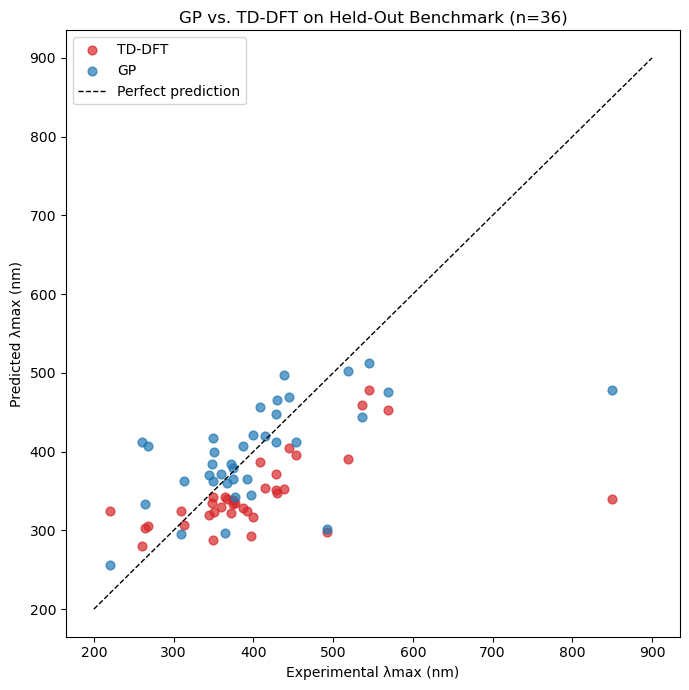

In [41]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true_eval36, df_eval36.set_index("canonical_smi").loc[eval36_smis_ordered, "lambda1_TDDFT_nm"],
            color="tab:red", alpha=0.7, s=40, label="TD-DFT")
plt.scatter(y_true_eval36, y_pred_eval36,
            color="tab:blue", alpha=0.7, s=40, label="GP")
plt.plot([200, 900], [200, 900], "k--", linewidth=1, label="Perfect prediction")
plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title(f"GP vs. TD-DFT on Held-Out Benchmark (n={len(y_true_eval36)})")
plt.legend()
plt.tight_layout()
plt.savefig("gp_vs_tddft_benchmark.png", dpi=300)
plt.show()

**Plot 2: sTDA vs. GP**

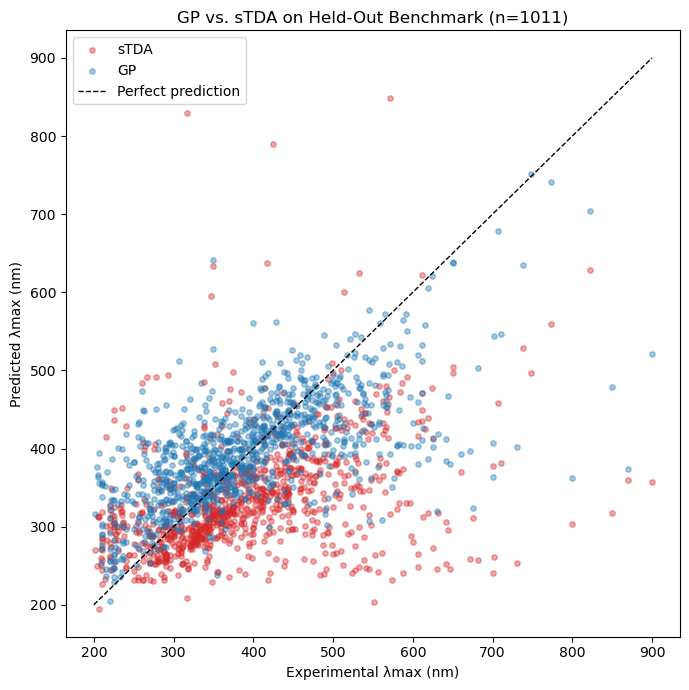

In [42]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true_eval_stda, df_stda_aligned["lambda1_sTDA_nm"].values,
            color="tab:red", alpha=0.4, s=15, label="sTDA")
plt.scatter(y_true_eval_stda, y_pred_eval_stda,
            color="tab:blue", alpha=0.4, s=15, label="GP")
plt.plot([200, 900], [200, 900], "k--", linewidth=1, label="Perfect prediction")
plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title(f"GP vs. sTDA on Held-Out Benchmark (n={len(y_true_eval_stda)})")
plt.legend()
plt.tight_layout()
plt.savefig("gp_vs_stda_benchmark.png", dpi=300)
plt.show()

**Load the solvent data and merge with your fingerprint representation**

In [46]:
df_solvent_et30 = pd.read_csv("solvent_et30_data.csv")
print(f"Loaded: {df_solvent_et30.shape[0]} rows")

# Merge with the main df (which has canonical_smi, fingerprints already computed as fp_df)
solvent_mask = df["canonical_smi"].isin(df_solvent_et30["canonical_smi"])
print(f"Compounds in main dataset with solvent info: {solvent_mask.sum()}")

df_fp_solvent = df[solvent_mask].merge(
    df_solvent_et30[["canonical_smi", "solvent_grouped", "et30"]],
    on="canonical_smi", how="inner"
)
print(f"After merge: {df_fp_solvent.shape[0]} rows")

# Get matching fingerprints for this subset
fp_solvent_subset = fp_df[solvent_mask.values].reset_index(drop=True)
print(f"Fingerprint subset shape: {fp_solvent_subset.shape}")

Loaded: 2084 rows
Compounds in main dataset with solvent info: 1989
After merge: 1998 rows
Fingerprint subset shape: (1989, 256)


**Build three parallel feature sets on this identical subset, for a clean, controlled comparison — fingerprint+conjugation alone, plus ET(30), plus one-hot solvent**

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

y_fp_solvent = df_fp_solvent["lambda_max_exp_nm"].reset_index(drop=True)

# Variant A: fingerprint + conjugation only (no solvent) -- the controlled baseline
X_A = pd.concat([fp_solvent_subset, df_fp_solvent[["LargestConjugatedSystemSize"]].reset_index(drop=True)], axis=1)

# Variant B: fingerprint + conjugation + ET(30)
X_B = pd.concat([X_A, df_fp_solvent[["et30"]].reset_index(drop=True)], axis=1)

# Variant C: fingerprint + conjugation + one-hot solvent
solvent_dummies_fp = pd.get_dummies(df_fp_solvent["solvent_grouped"].reset_index(drop=True), prefix="solvent")
X_C = pd.concat([X_A, solvent_dummies_fp], axis=1)

print(f"Variant A (fp+conj): {X_A.shape}")
print(f"Variant B (fp+conj+ET30): {X_B.shape}")
print(f"Variant C (fp+conj+onehot solvent): {X_C.shape}")

results = {}
for name, X in [("A: fp+conj", X_A), ("B: fp+conj+ET30", X_B), ("C: fp+conj+onehot", X_C)]:
    X_train, X_test, y_train, y_test = train_test_split(X, y_fp_solvent, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    ridge = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
    ridge.fit(X_train_s, y_train)
    pred = ridge.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = (rmse, r2)
    print(f"{name}: RMSE = {rmse:.2f} nm, R² = {r2:.3f}, alpha = {ridge.alpha_}")

Variant A (fp+conj): (1998, 257)
Variant B (fp+conj+ET30): (1998, 258)
Variant C (fp+conj+onehot solvent): (1998, 274)


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py", line 1238, in fit
    X, y = validate_data(
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/utils/validation.py", line 2971, 

**check whether these duplicate solvent entries actually agree with each other,**

In [48]:
# Check how many compounds have multiple solvent entries, and whether solvent choice differs
dup_solvent_check = df_solvent_et30.groupby("canonical_smi")["solvent_grouped"].nunique()
print(f"Compounds with multiple DIFFERENT solvents reported: {(dup_solvent_check > 1).sum()}")
print(f"Compounds with multiple entries but SAME solvent (just duplicate rows): {((df_solvent_et30.groupby('canonical_smi').size() > 1) & (dup_solvent_check == 1)).sum()}")

# Deduplicate: keep first entry per compound (reasonable given most duplicates likely share the same solvent)
df_solvent_et30_dedup = df_solvent_et30.drop_duplicates(subset="canonical_smi", keep="first").copy()
print(f"After deduplication: {df_solvent_et30_dedup.shape[0]} rows")

Compounds with multiple DIFFERENT solvents reported: 1
Compounds with multiple entries but SAME solvent (just duplicate rows): 8
After deduplication: 2074 rows


In [49]:
df_fp_solvent = df.merge(
    df_solvent_et30_dedup[["canonical_smi", "solvent_grouped", "et30"]],
    on="canonical_smi", how="inner"
).reset_index(drop=True)
print(f"After merge (deduplicated): {df_fp_solvent.shape[0]} rows")

fp_lookup = dict(zip(df["canonical_smi"], range(len(df))))
matched_positions = df_fp_solvent["canonical_smi"].map(fp_lookup)
fp_solvent_subset = fp_df.iloc[matched_positions].reset_index(drop=True)

print(f"Fingerprint subset shape: {fp_solvent_subset.shape}")
print(f"Row count match: {fp_solvent_subset.shape[0] == df_fp_solvent.shape[0]}")

After merge (deduplicated): 1989 rows
Fingerprint subset shape: (1989, 256)
Row count match: True


In [50]:
y_fp_solvent = df_fp_solvent["lambda_max_exp_nm"].reset_index(drop=True)

X_A = pd.concat([fp_solvent_subset, df_fp_solvent[["LargestConjugatedSystemSize"]].reset_index(drop=True)], axis=1)
X_B = pd.concat([X_A, df_fp_solvent[["et30"]].reset_index(drop=True)], axis=1)
solvent_dummies_fp = pd.get_dummies(df_fp_solvent["solvent_grouped"].reset_index(drop=True), prefix="solvent")
X_C = pd.concat([X_A, solvent_dummies_fp], axis=1)

print(f"Variant A (fp+conj): {X_A.shape}")
print(f"Variant B (fp+conj+ET30): {X_B.shape}")
print(f"Variant C (fp+conj+onehot solvent): {X_C.shape}")

results = {}
for name, X in [("A: fp+conj", X_A), ("B: fp+conj+ET30", X_B), ("C: fp+conj+onehot", X_C)]:
    X_train, X_test, y_train, y_test = train_test_split(X, y_fp_solvent, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    ridge = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
    ridge.fit(X_train_s, y_train)
    pred = ridge.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    results[name] = (rmse, r2)
    print(f"{name}: RMSE = {rmse:.2f} nm, R² = {r2:.3f}, alpha = {ridge.alpha_}")

Variant A (fp+conj): (1989, 257)
Variant B (fp+conj+ET30): (1989, 258)
Variant C (fp+conj+onehot solvent): (1989, 274)
A: fp+conj: RMSE = 100.48 nm, R² = 0.373, alpha = 500


ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py", line 1238, in fit
    X, y = validate_data(
  File "/Users/sahanawaz/miniforge3/envs/chemo_env/lib/python3.10/site-packages/sklearn/utils/validation.py", line 2971, 

In [51]:
print(f"NaN count in et30 column: {df_fp_solvent['et30'].isna().sum()}")
print(df_fp_solvent[df_fp_solvent['et30'].isna()]['solvent_grouped'].value_counts())

NaN count in et30 column: 45
solvent_grouped
Other    45
Name: count, dtype: int64


**filter these out before building Variant B specifically (Variant A and C don't need this, since A doesn't use et30 at all, and C's one-hot encoding handles "Other" as just another valid category, not a NaN)**

In [52]:
valid_et30_mask = df_fp_solvent["et30"].notna()
print(f"Rows with valid ET30: {valid_et30_mask.sum()} / {len(df_fp_solvent)}")

X_B_clean = X_B[valid_et30_mask.values].reset_index(drop=True)
y_B_clean = y_fp_solvent[valid_et30_mask.values].reset_index(drop=True)

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B_clean, y_B_clean, test_size=0.2, random_state=42)
scaler_B = StandardScaler()
X_train_B_s = scaler_B.fit_transform(X_train_B)
X_test_B_s = scaler_B.transform(X_test_B)
ridge_B = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
ridge_B.fit(X_train_B_s, y_train_B)
pred_B = ridge_B.predict(X_test_B_s)
rmse_B = np.sqrt(mean_squared_error(y_test_B, pred_B))
r2_B = r2_score(y_test_B, pred_B)
print(f"B: fp+conj+ET30 (n={len(X_B_clean)}): RMSE = {rmse_B:.2f} nm, R² = {r2_B:.3f}, alpha = {ridge_B.alpha_}")

Rows with valid ET30: 1944 / 1989
B: fp+conj+ET30 (n=1944): RMSE = 93.94 nm, R² = 0.369, alpha = 500


In [53]:
X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(X_C, y_fp_solvent, test_size=0.2, random_state=42)
scaler_C = StandardScaler()
X_train_C_s = scaler_C.fit_transform(X_train_C)
X_test_C_s = scaler_C.transform(X_test_C)
ridge_C = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
ridge_C.fit(X_train_C_s, y_train_C)
pred_C = ridge_C.predict(X_test_C_s)
rmse_C = np.sqrt(mean_squared_error(y_test_C, pred_C))
r2_C = r2_score(y_test_C, pred_C)
print(f"C: fp+conj+onehot (n={len(X_C)}): RMSE = {rmse_C:.2f} nm, R² = {r2_C:.3f}, alpha = {ridge_C.alpha_}")

C: fp+conj+onehot (n=1989): RMSE = 99.52 nm, R² = 0.385, alpha = 500


**rerun Variant A on the identical n=1,944 subset, so ET30's true marginal contribution is isolated**

In [54]:
X_A_matched = X_A[valid_et30_mask.values].reset_index(drop=True)
y_A_matched = y_fp_solvent[valid_et30_mask.values].reset_index(drop=True)

X_train_Am, X_test_Am, y_train_Am, y_test_Am = train_test_split(X_A_matched, y_A_matched, test_size=0.2, random_state=42)
scaler_Am = StandardScaler()
X_train_Am_s = scaler_Am.fit_transform(X_train_Am)
X_test_Am_s = scaler_Am.transform(X_test_Am)
ridge_Am = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
ridge_Am.fit(X_train_Am_s, y_train_Am)
pred_Am = ridge_Am.predict(X_test_Am_s)
rmse_Am = np.sqrt(mean_squared_error(y_test_Am, pred_Am))
r2_Am = r2_score(y_test_Am, pred_Am)

print(f"A (matched, n=1944, no ET30): RMSE = {rmse_Am:.2f} nm, R² = {r2_Am:.3f}")
print(f"B (n=1944, with ET30):        RMSE = 93.94 nm, R² = 0.369")
print(f"\nFor reference:")
print(f"A (full n=1989, no solvent):  RMSE = 100.48 nm, R² = 0.373")
print(f"C (n=1989, one-hot solvent):  RMSE = 99.52 nm, R² = 0.385")

A (matched, n=1944, no ET30): RMSE = 93.90 nm, R² = 0.370
B (n=1944, with ET30):        RMSE = 93.94 nm, R² = 0.369

For reference:
A (full n=1989, no solvent):  RMSE = 100.48 nm, R² = 0.373
C (n=1989, one-hot solvent):  RMSE = 99.52 nm, R² = 0.385


In [55]:
X_C_matched = X_C[valid_et30_mask.values].reset_index(drop=True)
y_C_matched = y_fp_solvent[valid_et30_mask.values].reset_index(drop=True)

X_train_Cm, X_test_Cm, y_train_Cm, y_test_Cm = train_test_split(X_C_matched, y_C_matched, test_size=0.2, random_state=42)
scaler_Cm = StandardScaler()
X_train_Cm_s = scaler_Cm.fit_transform(X_train_Cm)
X_test_Cm_s = scaler_Cm.transform(X_test_Cm)
ridge_Cm = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
ridge_Cm.fit(X_train_Cm_s, y_train_Cm)
pred_Cm = ridge_Cm.predict(X_test_Cm_s)
rmse_Cm = np.sqrt(mean_squared_error(y_test_Cm, pred_Cm))
r2_Cm = r2_score(y_test_Cm, pred_Cm)

print(f"C (matched, n=1944, one-hot solvent): RMSE = {rmse_Cm:.2f} nm, R² = {r2_Cm:.3f}")
print(f"A (matched, n=1944, no solvent):      RMSE = 93.90 nm, R² = 0.370")

C (matched, n=1944, one-hot solvent): RMSE = 93.91 nm, R² = 0.370
A (matched, n=1944, no solvent):      RMSE = 93.90 nm, R² = 0.370


**Reconstruct the sTDA-available subset with structural features (similar to what we did for the sTDA benchmark, but now keeping the residual itself as the object of study)**

In [56]:
col_names = [
    "SMI", "lambda1_sTDA_nm", "F1_sTDA", "lambda1_TDDFT_nm", "F1_TDDFT",
    "lambda_max_exp_nm", "extinction", "solvent"
]
df_raw = pd.read_csv("paper_allDB.csv", header=None, skiprows=1, names=col_names)

df_stda_full = df_raw[df_raw["lambda1_sTDA_nm"].notna()].copy()
df_stda_full["mol"] = df_stda_full["SMI"].apply(Chem.MolFromSmiles)
df_stda_full = df_stda_full[df_stda_full["mol"].notna()].copy()
df_stda_full["canonical_smi"] = df_stda_full["mol"].apply(Chem.MolToSmiles)

# Merge with your existing structural features (df already has canonical_smi, LargestConjugatedSystemSize, etc.)
df_stda_merged = df_stda_full.drop_duplicates(subset="canonical_smi").merge(
    df[["canonical_smi", "LargestConjugatedSystemSize", "NumDonorGroups", "NumAcceptorGroups", "HasPushPull"]],
    on="canonical_smi", how="inner"
)

df_stda_merged["stda_residual"] = df_stda_merged["lambda_max_exp_nm"] - df_stda_merged["lambda1_sTDA_nm"]

print(f"Compounds with sTDA + structural features: {df_stda_merged.shape[0]}")
print(df_stda_merged["stda_residual"].describe())

Compounds with sTDA + structural features: 5038
count    5038.000000
mean       59.795153
std       102.541005
min      -818.100000
25%        11.625000
50%        48.250000
75%        96.700000
max       588.900000
Name: stda_residual, dtype: float64


**Check whether the residual correlates with structural features — the actual diagnostic question**

In [57]:
for col in ["LargestConjugatedSystemSize", "NumDonorGroups", "NumAcceptorGroups", "HasPushPull"]:
    corr = df_stda_merged[col].corr(df_stda_merged["stda_residual"])
    print(f"Correlation (sTDA residual vs {col}): {corr:.3f}")

Correlation (sTDA residual vs LargestConjugatedSystemSize): -0.034
Correlation (sTDA residual vs NumDonorGroups): 0.131
Correlation (sTDA residual vs NumAcceptorGroups): 0.071
Correlation (sTDA residual vs HasPushPull): 0.070


**Build the matched fingerprint subset for these 5,038 compounds, using the same safe position-lookup approach that fixed our earlier alignment bug**

In [58]:
fp_lookup_stda = dict(zip(df["canonical_smi"], range(len(df))))
matched_positions_stda = df_stda_merged["canonical_smi"].map(fp_lookup_stda)

# Drop any that somehow don't match (shouldn't happen given the inner merge, but verify)
valid_match = matched_positions_stda.notna()
print(f"Matched positions found: {valid_match.sum()} / {len(df_stda_merged)}")

df_stda_merged = df_stda_merged[valid_match].reset_index(drop=True)
matched_positions_stda = matched_positions_stda[valid_match].astype(int).reset_index(drop=True)

fp_stda_subset = fp_df.iloc[matched_positions_stda].reset_index(drop=True)
print(f"Fingerprint subset shape: {fp_stda_subset.shape}")
print(f"Row count match: {fp_stda_subset.shape[0] == df_stda_merged.shape[0]}")

Matched positions found: 5038 / 5038
Fingerprint subset shape: (5038, 256)
Row count match: True


**Three-way controlled comparison, same split throughout**

In [59]:
y_stda_direct = df_stda_merged["lambda_max_exp_nm"].reset_index(drop=True)
y_stda_delta = df_stda_merged["stda_residual"].reset_index(drop=True)
stda_values = df_stda_merged["lambda1_sTDA_nm"].reset_index(drop=True)

# Variant 1: fingerprint + conjugation only (fair baseline, sTDA-subset-specific)
X1 = pd.concat([fp_stda_subset, df_stda_merged[["LargestConjugatedSystemSize"]].reset_index(drop=True)], axis=1)

# Variant 2: fingerprint + conjugation + sTDA as a direct feature, predicting lambda_max directly
X2 = pd.concat([X1, stda_values.rename("stda_value")], axis=1)

# Variant 3: fingerprint + conjugation (same X1), but predicting the DELTA, not lambda_max directly
X3 = X1.copy()

# Consistent split across all three (use one split, apply to all)
idx_train, idx_test = train_test_split(np.arange(len(X1)), test_size=0.2, random_state=42)

def eval_variant(X, y, name, add_back_stda=None):
    X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
    y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    ridge = RidgeCV(alphas=[10, 100, 500, 1000, 2000, 5000], cv=5)
    ridge.fit(X_train_s, y_train)
    pred = ridge.predict(X_test_s)

    if add_back_stda is not None:
        # Delta-learning: add sTDA back to get final lambda_max prediction
        stda_test = add_back_stda.iloc[idx_test].values
        final_pred = pred + stda_test
        true_lambda = df_stda_merged["lambda_max_exp_nm"].iloc[idx_test].values
        rmse = np.sqrt(mean_squared_error(true_lambda, final_pred))
        r2 = r2_score(true_lambda, final_pred)
    else:
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)

    print(f"{name}: RMSE = {rmse:.2f} nm, R² = {r2:.3f}, alpha = {ridge.alpha_}")

eval_variant(X1, y_stda_direct, "1: fp+conj only (baseline)")
eval_variant(X2, y_stda_direct, "2: fp+conj+sTDA (direct feature)")
eval_variant(X3, y_stda_delta, "3: fp+conj → delta (then +sTDA)", add_back_stda=stda_values)

1: fp+conj only (baseline): RMSE = 99.44 nm, R² = 0.186, alpha = 1000
2: fp+conj+sTDA (direct feature): RMSE = 95.43 nm, R² = 0.250, alpha = 1000
3: fp+conj → delta (then +sTDA): RMSE = 95.22 nm, R² = 0.254, alpha = 2000


In [60]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
import time
import joblib

# Use the same X2 (fingerprint + conjugation + sTDA feature) and same split as the Ridge test
X_train_gp_stda = X2.iloc[idx_train]
X_test_gp_stda = X2.iloc[idx_test]
y_train_gp_stda = y_stda_direct.iloc[idx_train]
y_test_gp_stda = y_stda_direct.iloc[idx_test]

scaler_gp_stda = StandardScaler()
X_train_gp_stda_scaled = scaler_gp_stda.fit_transform(X_train_gp_stda)
X_test_gp_stda_scaled = scaler_gp_stda.transform(X_test_gp_stda)

print(f"Train: {X_train_gp_stda_scaled.shape}, Test: {X_test_gp_stda_scaled.shape}")

kernel_gp_stda = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_stda = GaussianProcessRegressor(kernel=kernel_gp_stda, n_restarts_optimizer=2, random_state=42)

start = time.time()
print("Starting GP fit with sTDA feature...")
gp_stda.fit(X_train_gp_stda_scaled, y_train_gp_stda)
print(f"Done in {time.time() - start:.1f} seconds.")
print(gp_stda.kernel_)

y_pred_gp_stda, y_std_gp_stda = gp_stda.predict(X_test_gp_stda_scaled, return_std=True)
rmse_gp_stda = np.sqrt(mean_squared_error(y_test_gp_stda, y_pred_gp_stda))
r2_gp_stda = r2_score(y_test_gp_stda, y_pred_gp_stda)
calib_gp_stda = np.corrcoef(y_std_gp_stda, np.abs(y_test_gp_stda.values - y_pred_gp_stda))[0, 1]

print(f"GP + sTDA feature (n={len(X2)}): RMSE = {rmse_gp_stda:.2f} nm, R² = {r2_gp_stda:.3f}")
print(f"Calibration r: {calib_gp_stda:.3f}")

joblib.dump(gp_stda, "gp_stda_model.joblib")
joblib.dump(scaler_gp_stda, "scaler_gp_stda.joblib")
print("Model saved.")

Train: (4030, 258), Test: (1008, 258)
Starting GP fit with sTDA feature...
Done in 530.9 seconds.
161**2 * RBF(length_scale=17.4) + WhiteKernel(noise_level=3.33e+03)
GP + sTDA feature (n=5038): RMSE = 81.04 nm, R² = 0.459
Calibration r: 0.140
Model saved.


**Fair Comparison**

In [61]:
X_train_gp_base = X1.iloc[idx_train]
X_test_gp_base = X1.iloc[idx_test]

scaler_gp_base = StandardScaler()
X_train_gp_base_scaled = scaler_gp_base.fit_transform(X_train_gp_base)
X_test_gp_base_scaled = scaler_gp_base.transform(X_test_gp_base)

kernel_gp_base = (
    ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e5))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e4))
    + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-3, 1e6))
)

gp_base_matched = GaussianProcessRegressor(kernel=kernel_gp_base, n_restarts_optimizer=2, random_state=42)

start = time.time()
print("Starting matched baseline GP fit (no sTDA)...")
gp_base_matched.fit(X_train_gp_base_scaled, y_train_gp_stda)
print(f"Done in {time.time() - start:.1f} seconds.")

y_pred_gp_base, y_std_gp_base = gp_base_matched.predict(X_test_gp_base_scaled, return_std=True)
rmse_gp_base = np.sqrt(mean_squared_error(y_test_gp_stda, y_pred_gp_base))
r2_gp_base = r2_score(y_test_gp_stda, y_pred_gp_base)

print(f"GP, fp+conj only, MATCHED subset (n={len(X1)}): RMSE = {rmse_gp_base:.2f} nm, R² = {r2_gp_base:.3f}")
print(f"\nFor comparison:")
print(f"GP + sTDA feature (same subset): RMSE = 81.04 nm, R² = 0.459")

import joblib
joblib.dump(gp_base_matched, "gp_base_matched_model.joblib")

Starting matched baseline GP fit (no sTDA)...
Done in 584.5 seconds.
GP, fp+conj only, MATCHED subset (n=5038): RMSE = 83.32 nm, R² = 0.429

For comparison:
GP + sTDA feature (same subset): RMSE = 81.04 nm, R² = 0.459


['gp_base_matched_model.joblib']